In [2]:
import os
os.chdir("D:/Projects/volatility-radar")

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("data/processed/full_merged.csv")

df['date'] = pd.to_datetime(df['date'])

# ── 2. clean numeric values ──────────────────────────────────
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if not val or val.lower() == 'nan':
        return np.nan
    # bond auction — keep yield (first value before |)
    if '|' in val:
        val = val.split('|')[0]
    # remove % sign
    val = val.replace('%', '')
    # handle K M B T multipliers
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12}
    for suffix, multiplier in multipliers.items():
        if val.upper().endswith(suffix):
            try:
                return float(val[:-1]) * multiplier
            except:
                return np.nan
    try:
        return float(val)
    except:
        return np.nan

df['actual_clean'] = df['actual'].apply(clean_numeric)
df['previous_clean'] = df['previous'].apply(clean_numeric)

# ── 3. drop original actual/previous, rename clean columns ───
df.drop(columns=['actual', 'previous'], inplace=True)
df.rename(columns={'actual_clean': 'actual', 'previous_clean': 'previous'}, inplace=True)

# ── 4. compute surprise ──────────────────────────────────────
df['surprise'] = df['actual'] - df['previous']

# ── 5. encode impact ─────────────────────────────────────────
impact_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['impact_score'] = df['impact'].map(impact_map)

# ── 6. drop rows where actual is null ────────────────────────
# these are events with no reportable number (speeches, meetings)
before = df.shape[0]
df.dropna(subset=['actual'], inplace=True)
after = df.shape[0]
print(f"Dropped {before - after} rows with no actual value")

# ── 7. final check ───────────────────────────────────────────
print(f"\nFinal shape: {df.shape}")
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nSample:")
print(df.head(3))

# ── 8. save ──────────────────────────────────────────────────
df.to_csv("data/processed/full_merged_clean.csv", index=False)
print("\nSaved to data/processed/full_merged_clean.csv")

Dropped 92 rows with no actual value

Final shape: (23399, 14)

Null counts:
date            0
time            0
currency        0
event           0
impact          0
pair            0
open            0
high            0
low             0
close           0
actual          0
previous        3
surprise        3
impact_score    0
dtype: int64

Sample:
        date    time currency                           event impact    pair  \
0 2021-01-04  1:45pm      EUR       Spanish Manufacturing PMI    Low  EURUSD   
1 2021-01-04  2:15pm      EUR       Italian Manufacturing PMI    Low  EURUSD   
2 2021-01-04  2:20pm      EUR  French Final Manufacturing PMI    Low  EURUSD   

      open     high     low    close  actual  previous  surprise  impact_score  
0  1.22386  1.23098  1.2229  1.22461    51.0      49.8       1.2             1  
1  1.22386  1.23098  1.2229  1.22461    52.8      51.5       1.3             1  
2  1.22386  1.23098  1.2229  1.22461    51.1      51.1       0.0             1  

Sav

In [4]:
df.dropna(subset=['previous', 'surprise'], inplace=True)
print(df.shape)
print(df.isnull().sum())
df.to_csv("data/processed/full_merged_clean.csv", index=False)

(23396, 14)
date            0
time            0
currency        0
event           0
impact          0
pair            0
open            0
high            0
low             0
close           0
actual          0
previous        0
surprise        0
impact_score    0
dtype: int64


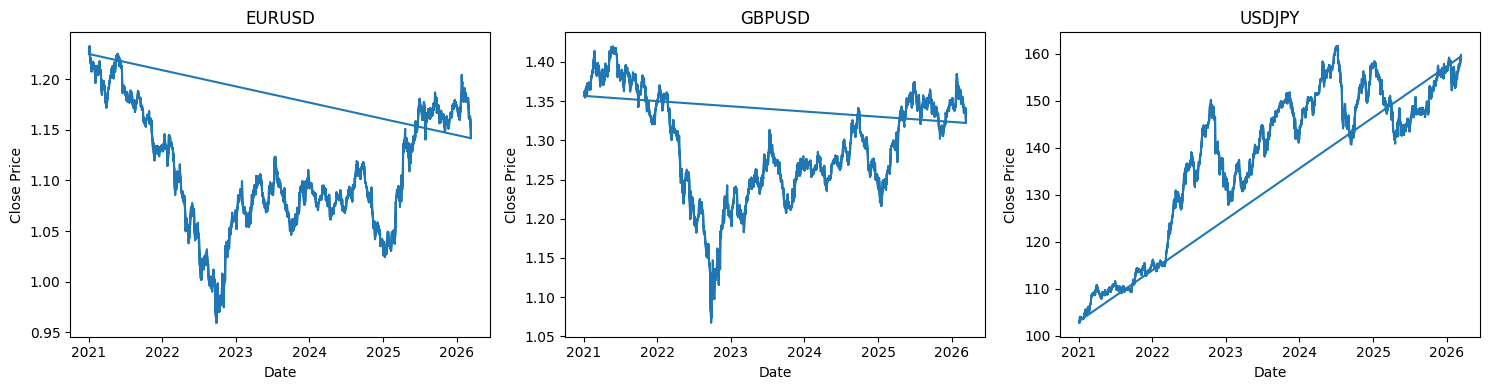

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pair in zip(axes, ['EURUSD', 'GBPUSD', 'USDJPY']):
    pair_df = df[df['pair'] == pair]
    ax.plot(pair_df['date'], pair_df['close'])
    ax.set_title(pair)
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')

plt.tight_layout()
plt.show()

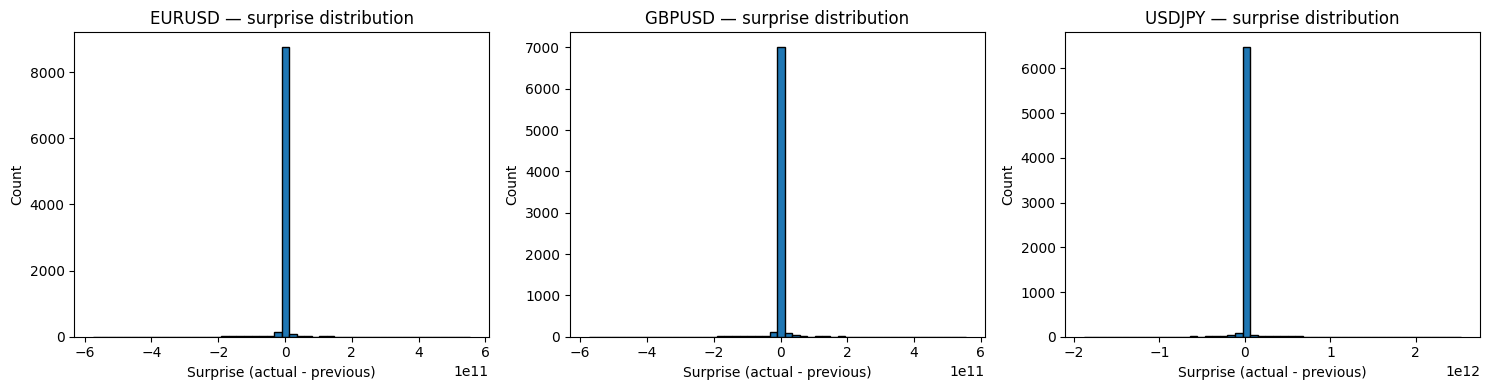

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pair in zip(axes, ['EURUSD', 'GBPUSD', 'USDJPY']):
    pair_df = df[df['pair'] == pair]
    ax.hist(pair_df['surprise'], bins=50, edgecolor='black')
    ax.set_title(f'{pair} — surprise distribution')
    ax.set_xlabel('Surprise (actual - previous)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
event_std = df.groupby('event')['previous'].std()

df['previous_std'] = df['event'].map(event_std)

df['surprise_normalized'] = df['surprise'] / df['previous_std']

print(df['surprise_normalized'].isnull().sum())
print(df['surprise_normalized'].describe())

33
count    23363.000000
mean        -0.009508
std          0.864178
min         -9.649695
25%         -0.241858
50%          0.000000
75%          0.228503
max          9.756022
Name: surprise_normalized, dtype: float64


In [8]:
df.dropna(subset=['surprise_normalized'], inplace=True)
df.drop(columns=['previous_std'], inplace=True)
print(df.shape)

(23363, 15)


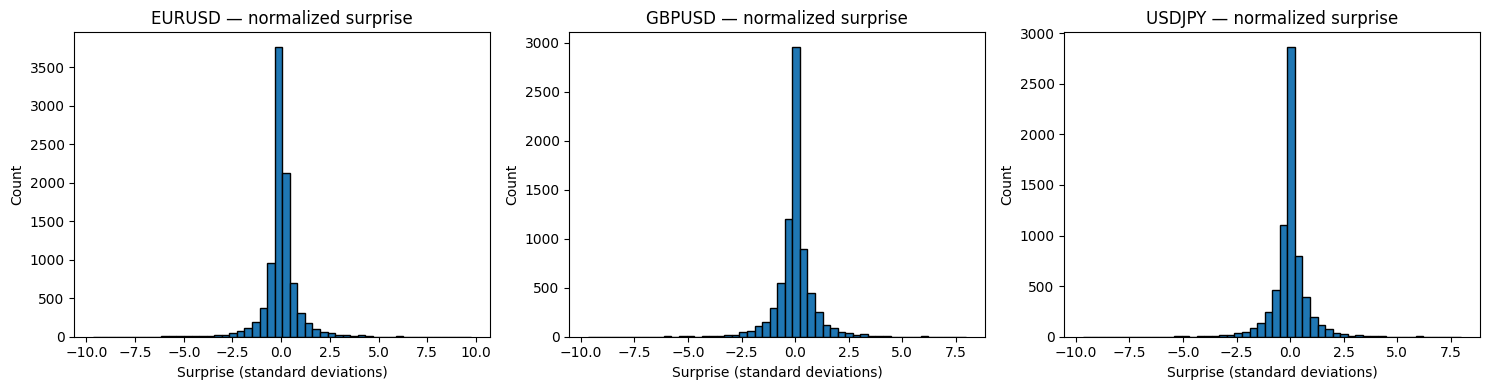

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pair in zip(axes, ['EURUSD', 'GBPUSD', 'USDJPY']):
    pair_df = df[df['pair'] == pair]
    ax.hist(pair_df['surprise_normalized'], bins=50, edgecolor='black')
    ax.set_title(f'{pair} — normalized surprise')
    ax.set_xlabel('Surprise (standard deviations)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
high_impact = df[df['impact'] == 'High']

top_surprises = high_impact.groupby('event')['surprise_normalized'].agg(['mean', 'std', 'count'])
top_surprises = top_surprises[top_surprises['count'] >= 10]
top_surprises['abs_mean'] = top_surprises['mean'].abs()
top_surprises = top_surprises.sort_values('abs_mean', ascending=False)

print(top_surprises.head(15))

                                        mean       std  count  abs_mean
event                                                                  
Prelim Benchmark Payrolls Revision -0.440760  1.305719     12  0.440760
Pending Home Sales m/m              0.411455  1.588188     15  0.411455
Claimant Count Change               0.369403  0.654393     35  0.369403
Advance GDP q/q                    -0.251522  0.998222     60  0.251522
French Flash Services PMI          -0.131285  0.589185     39  0.131285
Prelim UoM Inflation Expectations   0.104143  0.861832     30  0.104143
German Prelim CPI m/m              -0.095563  0.700796     28  0.095563
ADP Non-Farm Employment Change     -0.093104  0.902233    165  0.093104
Employment Cost Index q/q          -0.081349  0.794521     33  0.081349
Federal Funds Rate                  0.079857  0.246891     93  0.079857
Empire State Manufacturing Index    0.060401  1.302083     69  0.060401
JOLTS Job Openings                 -0.057967  0.233230    153  0

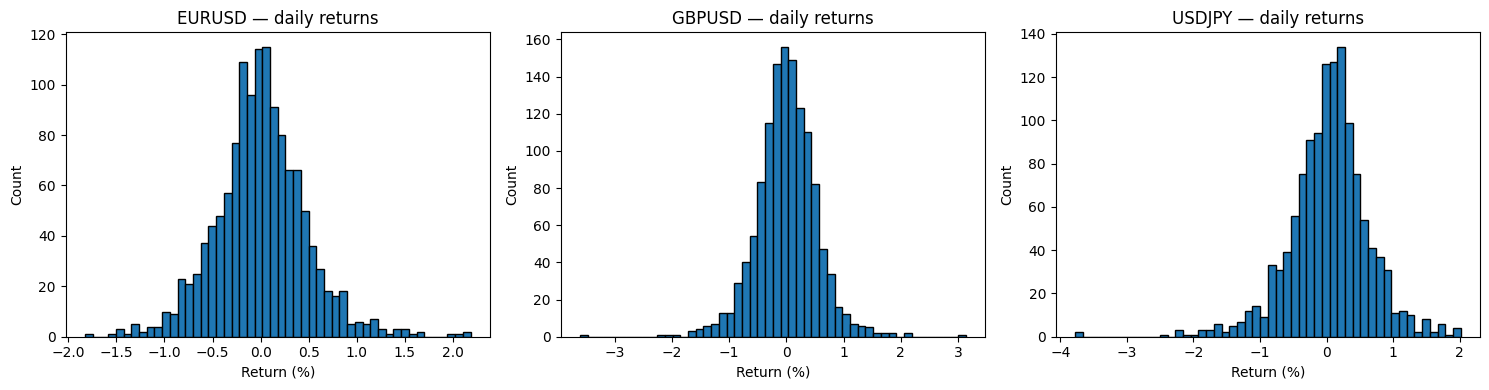

In [11]:
# daily return per pair
df['daily_return'] = (df['close'] - df['open']) / df['open'] * 100

# plot return distribution per pair
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pair in zip(axes, ['EURUSD', 'GBPUSD', 'USDJPY']):
    pair_df = df[df['pair'] == pair].drop_duplicates(subset=['date'])
    ax.hist(pair_df['daily_return'], bins=50, edgecolor='black')
    ax.set_title(f'{pair} — daily returns')
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()